Standardiztion


In [2]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv('Social_Network_Ads.csv')
df=df.drop(['User ID','Gender'],axis=1)
df.sample(5)

,Age,EstimatedSalary,Purchased
343,47,51000,1
183,33,43000,0
352,42,90000,1
22,48,41000,1
153,36,50000,0


In [4]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.2)
X_train.sample(5)
X_test["Age"].head()

177    25
148    29
77     22
355    60
310    42
Name: Age, dtype: int64

In [5]:
sc=StandardScaler()
sc.fit(X_train)
X_train_scaled=sc.transform(X_train)
X_test_scaled=sc.transform(X_test)
sc.mean_
# X_test_scaled.shape

array([3.7815625e+01, 7.1887500e+04])

In [6]:
sc.mean_
# print(X_train.head())
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_train_scaled.head()
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)
X_test_scaled.shape

(80, 2)

In [7]:
np.round(X_test_scaled.describe(),5)

,Age,EstimatedSalary
count,80.00000,80.00000
mean,-0.07547,-0.31250
std,0.91969,0.92489
min,-1.76812,-1.65756
25%,-0.82841,-1.10395
50%,-0.17062,-0.41922
75%,0.39321,0.21452
max,2.08468,2.27600


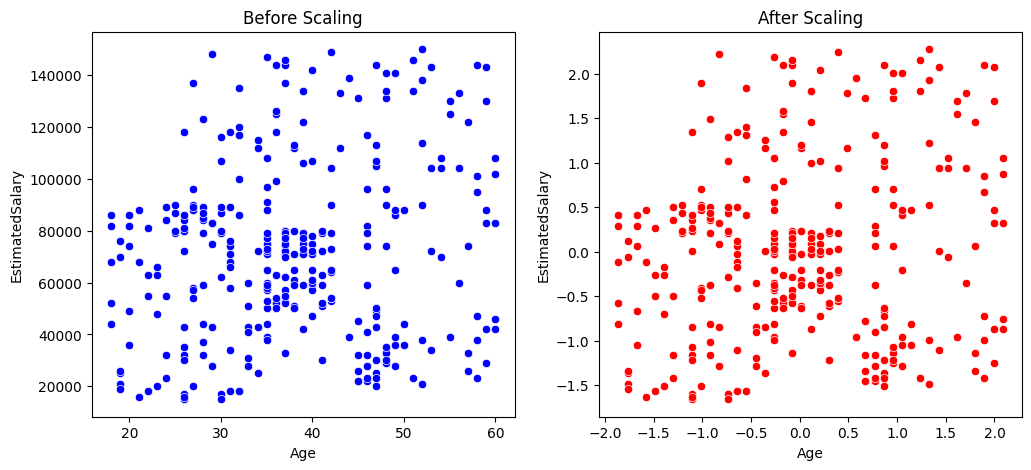

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
fig ,ax=plt.subplots(1,2,figsize=(12,5))
sns.scatterplot(x=X_train['Age'],y=X_train['EstimatedSalary'],ax=ax[0],color='blue')
ax[0].set_title('Before Scaling')
sns.scatterplot(x=X_train_scaled['Age'],y=X_train_scaled['EstimatedSalary'],color='red',ax=ax[1])

ax[1].set_title('After Scaling')

plt.show()

Text(0.5, 1.0, 'After Scaling')

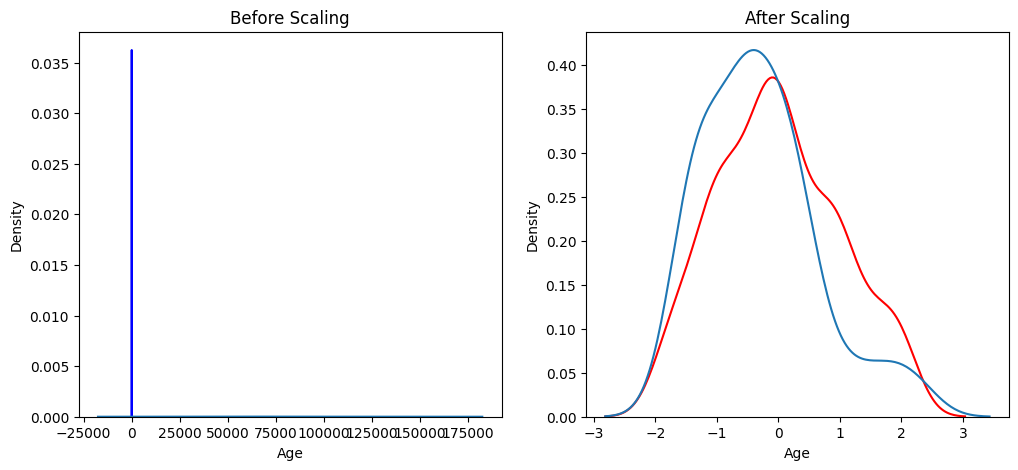

In [9]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
sns.kdeplot(X_train['Age'],ax=ax[0],fill=False,color='blue')
sns.kdeplot(X_train['EstimatedSalary'],ax=ax[0])
ax[0].set_title('Before Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax[1],fill=False,color='red')
sns.kdeplot(X_test_scaled['EstimatedSalary'],ax=ax[1])
ax[1].set_title('After Scaling')


In [10]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr_scaled=LogisticRegression()
X_test_scaled.shape

(80, 2)

In [11]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
y_pred=lr.predict(X_test)
print(y_pred.shape)
Y_pred_scaled=lr_scaled.predict(X_test_scaled)
Y_pred_scaled.shape

(80,)


(80,)

In [13]:
from sklearn.metrics import accuracy_score
print("Accuracy : ", accuracy_score(y_test,y_pred))
print("Accuracy Scaled: ", accuracy_score(y_test,Y_pred_scaled))

Accuracy :  0.9125
Accuracy Scaled:  0.9125


In [14]:
df=pd.concat([df,pd.DataFrame([[5, 1000000, 0],
    [90, 2350000, 1],
    [100, 3000000, 1]
    ],columns=['Age','EstimatedSalary', 'Purchased'])],ignore_index=True)
df.tail()

,Age,EstimatedSalary,Purchased
398,36,33000,0
399,49,36000,1
400,5,1000000,0
401,90,2350000,1
402,100,3000000,1


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

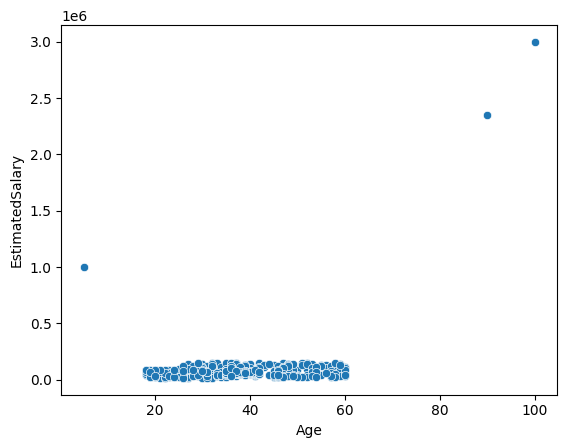

In [67]:
sns.scatterplot(x=df['Age'],y=df['EstimatedSalary'])

In [68]:
X_train,X_test,y_train,Y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.2)


In [76]:
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

Text(0.5, 1.0, 'After scaling')

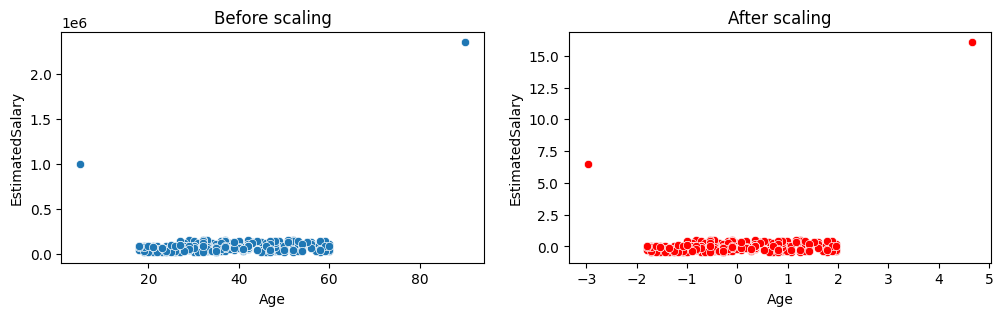

In [78]:
fig,ax=plt.subplots(1,2,figsize=(12,3))
sns.scatterplot(x=X_train['Age'],y=X_train['EstimatedSalary'],ax=ax[0])
ax[0].set_title('Before scaling')
sns.scatterplot(x=X_train_scaled['Age'],y=X_train_scaled['EstimatedSalary'],color='red',ax=ax[1])
ax[1].set_title('After scaling')